# TUS simulation safety parameter plots

In [1]:
import utils
import os
import glob
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

pd.set_option('display.max_rows', None)

In [2]:
planning_simulations = False

# Determine simulation location
if planning_simulations:
    simulations_location = 'planning'
else:
    simulations_location = 'post-hoc'

# Make output folder
plot_dir = f'/Volumes/kenvdzee/Documents/phd_1_analysis/plots/TUS/acoustic_simulations/{simulations_location}'
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

### Find all csv's from the stimulation output folder

In [3]:
simulation_directory = f'/Volumes/project/3025011.02/TUS_simulations/{simulations_location}/'

stimulation_output_full_filenames_1 = os.path.join(simulation_directory, '**', '*layered_output_table_target_1*.csv')
stimulation_output_full_filenames_2 = os.path.join(simulation_directory, '**', '*layered_output_table_target_2*.csv')
stimulation_output_full_filenames_3 = os.path.join(simulation_directory, '**', '*layered_output_table_target_3*.csv')

stimulation_output_full_filenames = glob.glob(stimulation_output_full_filenames_1, recursive=True) + glob.glob(stimulation_output_full_filenames_2, recursive=True) + glob.glob(stimulation_output_full_filenames_3, recursive=True)
print(stimulation_output_full_filenames)

['/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-052/sub-052_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-053/sub-053_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-054/sub-054_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-057/sub-057_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-061/sub-061_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-058/sub-058_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-060/sub-060_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/

### Save them in one dataframe
And add columns with the individual subject_id's, targets etc

In [4]:
# List to hold individual dataframes
list_of_dataframes = []

# Process each CSV file
for stimulation_output_full_filename in stimulation_output_full_filenames:
    # Extract the filename (without the path)
    stimulation_output_filename = os.path.basename(stimulation_output_full_filename)
    # Remove the '.csv' extension
    stimulation_output_filename_without_extension = os.path.splitext(stimulation_output_filename)[0]
    
    # Split the filename by underscores
    stimulation_output_filename_parts = stimulation_output_filename_without_extension.split('_')
    
    # Extract the desired parts from the filename:
    subject_id = stimulation_output_filename_parts[0]                     # e.g. 'sub-010'
    target = '_'.join(stimulation_output_filename_parts[4:7])               # e.g. 'target_2_2'
    
    # Read the CSV file (assuming it contains one row)
    try:
        df = pd.read_csv(stimulation_output_full_filename)
    except Exception as e:
        print(f"Error reading {stimulation_output_full_filename}: {e}")
        continue  # Skip this file if there's an error

    # Add the extracted metadata as new columns
    df['target'] = target
    
    # Append the dataframe to our list
    list_of_dataframes.append(df)

# Combine all dataframes into one
if list_of_dataframes:
    stimulation_output = pd.concat(list_of_dataframes, ignore_index=True)
    print(stimulation_output)
else:
    raise Exception("No CSV files were found or processed.")

     subject_id  max_Isppa  max_Isppa_after_exit_plane  real_focal_distance  \
0            52  32.001720                   16.893220             0.000000   
1            53  28.800580                   25.415650             3.000000   
2            54  28.089220                   20.357300             3.000000   
3            57  33.969000                   19.630080             2.500000   
4            61  29.615720                   20.811000             1.000000   
5            58  36.404690                   15.432150             2.500000   
6            60  35.776040                   19.817120             2.500000   
7            64  30.313290                   19.792390             2.000000   
8            65  28.495440                   24.902610             2.500000   
9            66  32.014370                   20.251230             2.000000   
10           67  35.792700                   20.511710             3.000000   
11           68  29.654730                   24.3703

### Reorder the dataframe and replace strings

In [5]:
# Reorder columns
column_indices = list(range(stimulation_output.shape[1]))
reordered_column_indices = [column_indices[0]] + column_indices[-3:] + column_indices[1:-3]
stimulation_output = stimulation_output.iloc[:, reordered_column_indices]
stimulation_output.sort_values(by=['subject_id', 'target'], inplace=True)
stimulation_output.reset_index(drop=True, inplace=True)

# Now drop some columns
stimulation_output.drop(
    ['real_focal_distance','Ix_brain', 'Iy_brain','Iz_brain',
     'focus_pos_final_1', 'focus_pos_final_2', 'focus_pos_final_3',
     'trans_pos_final_1', 'trans_pos_final_2', 'trans_pos_final_3'],
    axis=1,
    inplace=True
)

# Split target up into two
stimulation_output[['main_target', 'sub_target']] = stimulation_output['target'].str.extract(r'(target_\d+)_(\d+)')

print(stimulation_output)

     subject_id  CEM43_end_skull  CEM43_end_skin      target  max_Isppa  \
0            48         0.000265        0.000255  target_3_1  11.103430   
1            48         0.000543        0.000541  target_3_2  10.139190   
2            48         0.000806        0.000798  target_3_3  10.601070   
3            48         0.001096        0.001073  target_3_4  10.139190   
4            52         0.002353        0.000860  target_1_1  32.001720   
5            52         0.007632        0.001496  target_1_2  28.027400   
6            52         0.008368        0.003084  target_1_3  30.959480   
7            52         0.018752        0.005300  target_1_4  27.009890   
8            52         0.020532        0.005727  target_1_5  32.419980   
9            52         0.034939        0.009014  target_1_6  28.358610   
10           52         0.066493        0.001263  target_2_1  35.852970   
11           52         0.000281        0.000270  target_3_1  10.746800   
12           52         0

# Mechanical index
1.9 is the safety limit
Group by target and intensity

In [6]:
safety_limit = 1.9

## Skin

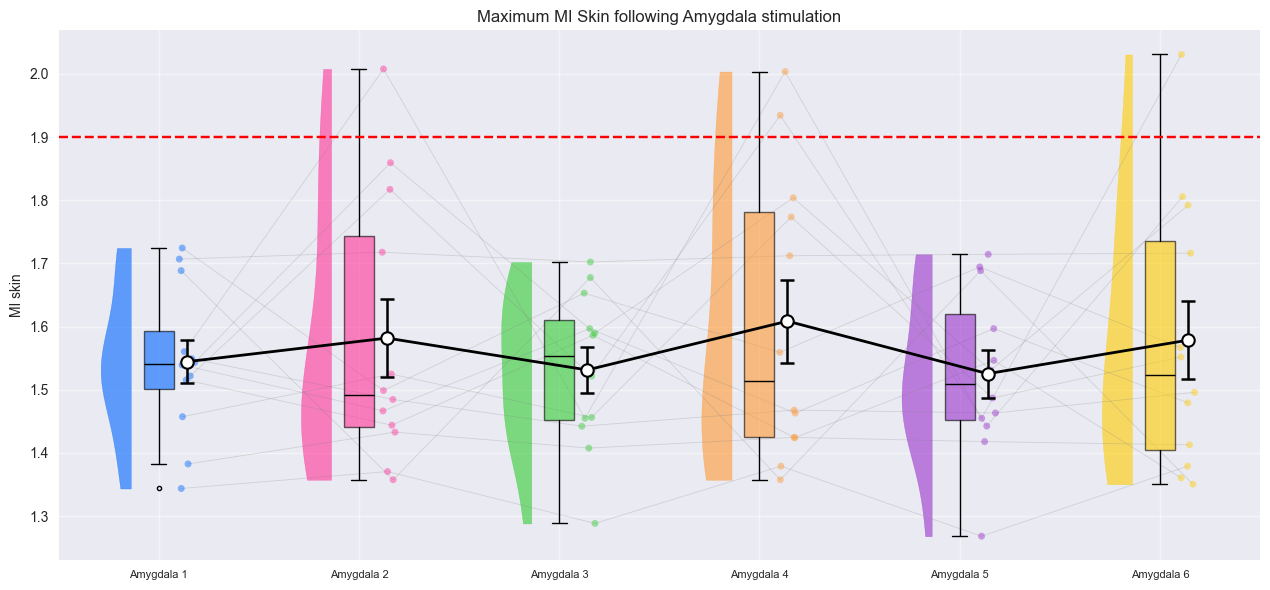

In [7]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    labels=['Amygdala 1', 'Amygdala 2', 'Amygdala 3', 'Amygdala 4', 'Amygdala 5', 'Amygdala 6'],
    output_dir=plot_dir,
    ylabel_name='MI skin',
    hline=safety_limit,
    plot_name='Maximum MI Skin following Amygdala stimulation'
);

In [8]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    labels=['dACC 1', 'dACC 2', 'dACC 3', 'dACC 4', 'dACC 5', 'dACC 6'],
    output_dir=plot_dir,
    ylabel_name='MI skin',
    hline=safety_limit,
    plot_name='Maximum MI Skin following dACC stimulation'
);

KeyError: "['target_2_6'] not in index"

In [ ]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    labels=['Defocused 1', 'Defocused 2', 'Defocused 3', 'Defocused 4', 'Defocused 5', 'Defocused 6'],
    output_dir=plot_dir,
    ylabel_name='MI skin',
    hline=safety_limit,
    plot_name='Maximum MI Skin following Defocused stimulation'
);

In [ ]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id','sub_target'],
        columns='main_target',
        values='max_MI_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1', 'target_2', 'target_3'],
    labels=['Amygdala', 'dACC', 'Defocused'],
    colours=['firebrick', 'royalblue','darkgrey'],
    output_dir=plot_dir,
    ylabel_name='MI skin',
    hline=safety_limit,
    plot_name='Maximum MI Skin',
    font_scale=1.6
);

In [10]:
stimulation_output_exceeded = stimulation_output[stimulation_output['max_MI_skin'] > safety_limit]
print(stimulation_output_exceeded[['subject_id','target','max_MI_skin']])

     subject_id      target  max_MI_skin
10           52  target_2_1     2.048062
23           53  target_2_1     2.120551
24           53  target_2_2     1.977403
25           53  target_2_3     2.243156
38           54  target_2_1     2.061130
47           55  target_2_3     1.932492
48           55  target_2_4     1.975965
62           57  target_2_1     2.061263
75           58  target_2_1     2.553261
76           58  target_2_2     2.336116
77           58  target_2_3     2.097762
78           58  target_2_4     2.233585
79           58  target_2_5     2.364889
90           60  target_2_1     2.266523
92           60  target_2_3     2.043717
98           61  target_1_2     2.007865
100          61  target_1_4     2.003708
102          61  target_1_6     2.030748
103          61  target_2_1     2.287953
104          61  target_2_2     2.033566
105          61  target_2_3     2.382491
106          61  target_2_4     2.266668
107          61  target_2_5     2.268851
114          63 

## Brain

In [ ]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    labels=['Amygdala 1', 'Amygdala 2', 'Amygdala 3', 'Amygdala 4', 'Amygdala 5', 'Amygdala 6'],
    output_dir=plot_dir,
    ylabel_name='MItc',
    hline=safety_limit,
    plot_name='Maximum MItc following Amygdala stimulation'
);

In [ ]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    labels=['dACC 1', 'dACC 2', 'dACC 3', 'dACC 4', 'dACC 5', 'dACC 6'],
    output_dir=plot_dir,
    ylabel_name='MItc',
    hline=safety_limit,
    plot_name='Maximum MItc following dACC stimulation'
);

In [ ]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    labels=['Defocused 1', 'Defocused 2', 'Defocused 3', 'Defocused 4', 'Defocused 5', 'Defocused 6'],
    output_dir=plot_dir,
    ylabel_name='MItc',
    hline=safety_limit,
    plot_name='Maximum MItc following Defocused stimulation'
);

In [ ]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id','sub_target'],
        columns='main_target',
        values='max_MI_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1', 'target_2', 'target_3'],
    labels=['Amygdala', 'dACC', 'Defocused'],
    colours=['firebrick', 'royalblue','darkgrey'],
    output_dir=plot_dir,
    ylabel_name='MItc',
    hline=safety_limit,
    plot_name='Maximum MItc',
    font_scale=1.6
);

In [ ]:
stimulation_output_exceeded = stimulation_output[stimulation_output['max_MI_brain'] > safety_limit]
print(stimulation_output_exceeded[['subject_id','target','max_MI_brain']])

# CEM43
0.25 is the safety limit
Group by target and intensity

## Skin

In [ ]:
safety_limit = 21

In [ ]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    labels=['Amygdala 1', 'Amygdala 2', 'Amygdala 3', 'Amygdala 4', 'Amygdala 5', 'Amygdala 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skin [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 Skin following Amygdala stimulation',
    logarithmic_scale=True
);

In [ ]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    labels=['dACC 1', 'dACC 2', 'dACC 3', 'dACC 4', 'dACC 5', 'dACC 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 Skin [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 Skin following dACC stimulation',
    logarithmic_scale=True
);

In [ ]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    labels=['Defocused 1', 'Defocused 2', 'Defocused 3', 'Defocused 4', 'Defocused 5', 'Defocused 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 Skin [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 Skin following Defocused stimulation',
    logarithmic_scale=True
);

In [ ]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id','sub_target'],
        columns='main_target',
        values='CEM43_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1', 'target_2', 'target_3'],
    labels=['Amygdala', 'dACC', 'Defocused'],
    colours=['firebrick', 'royalblue','darkgrey'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skin [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 skin',
    logarithmic_scale=True,
    font_scale=1.6
);

In [ ]:
stimulation_output_exceeded = stimulation_output[stimulation_output['CEM43_skin'] > safety_limit]
print(stimulation_output_exceeded[['subject_id','target','CEM43_skin']])

## Brain

In [ ]:
safety_limit = 2

In [ ]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    labels=['Amygdala 1', 'Amygdala 2', 'Amygdala 3', 'Amygdala 4', 'Amygdala 5', 'Amygdala 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 brain [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 brain following Amygdala stimulation',
    logarithmic_scale=True
);

In [ ]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    labels=['dACC 1', 'dACC 2', 'dACC 3', 'dACC 4', 'dACC 5', 'dACC 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 brain [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 brain following dACC stimulation',
    logarithmic_scale=True
);

In [ ]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    labels=['Defocused 1', 'Defocused 2', 'Defocused 3', 'Defocused 4', 'Defocused 5', 'Defocused 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 brain [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 brain following Defocused stimulation',
    logarithmic_scale=True
);

In [ ]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id','sub_target'],
        columns='main_target',
        values='CEM43_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1', 'target_2', 'target_3'],
    labels=['Amygdala', 'dACC', 'Defocused'],
    colours=['firebrick', 'royalblue','darkgrey'],
    output_dir=plot_dir,
    ylabel_name='CEM43 brain [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 brain',
    logarithmic_scale=True,
    font_scale=1.6
);

In [ ]:
stimulation_output_exceeded = stimulation_output[stimulation_output['CEM43_brain'] > safety_limit]
print(stimulation_output_exceeded[['subject_id','target','CEM43_brain']])

## Skull

In [ ]:
safety_limit = 16

In [ ]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    labels=['Amygdala 1', 'Amygdala 2', 'Amygdala 3', 'Amygdala 4', 'Amygdala 5', 'Amygdala 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skull [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 skull following Amygdala stimulation',
    logarithmic_scale=True
);

In [ ]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    labels=['dACC 1', 'dACC 2', 'dACC 3', 'dACC 4', 'dACC 5', 'dACC 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skull [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 skull following dACC stimulation',
    logarithmic_scale=True
);

In [ ]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    labels=['Defocused 1', 'Defocused 2', 'Defocused 3', 'Defocused 4', 'Defocused 5', 'Defocused 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skull [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 skull following Defocused stimulation',
    logarithmic_scale=True
);


In [ ]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id','sub_target'],
        columns='main_target',
        values='CEM43_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1', 'target_2', 'target_3'],
    labels=['Amygdala', 'dACC', 'Defocused'],
    colours=['firebrick', 'royalblue','darkgrey'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skull [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 skull',
    logarithmic_scale=True,
    font_scale=1.6
);

In [ ]:
stimulation_output_exceeded = stimulation_output[stimulation_output['CEM43_skull'] > safety_limit]
print(stimulation_output_exceeded[['subject_id','target','CEM43_skull']])